# XBeach Forcing Tutorial

This tutorial demonstrates how to generate **wind** and **tide** forcing for XBeach
from **geolocated data sources** (gridded and station-based datasets).

For forcing from simple timeseries data (CSV files, buoy observations), see the
**Bulk Forcing Tutorial** which covers point-based data without geolocation.

## What You'll Learn

- Generate wind forcing from gridded (e.g., ERA5) and station data
- Generate tide forcing from tidal constituents (gridded and point)
- Generate water level forcing from timeseries data
- Inspect generated files and visualize the data

In [1]:
from pathlib import Path
from datetime import timedelta
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import warnings
warnings.filterwarnings("ignore")

## Setup

In [2]:
# Data and output directories
DATA_DIR = Path("../../../../rompy-xbeach/tests/data")
OUT_DIR = Path("forcing-tutorial-output")

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir()

In [3]:
from rompy.core.time import TimeRange
from rompy_xbeach.grid import RegularGrid

# Model times
times = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")

# Model grid
grid = RegularGrid(
    ori=dict(x=115.594239, y=-32.641104, crs="epsg:4326"),
    alfa=347.0,
    dx=10,
    dy=15,
    nx=230,
    ny=220,
    crs="28350",
)

In [4]:
def print_params(params: dict, filename: str = "params.txt"):
    """Display parameters in a text-editor style format."""
    border = "─" * 60
    print(f"┌{border}┐")
    print(f"│ {filename:<58} │")
    print(f"├{border}┤")
    for k, v in params.items():
        line = f"{k} = {v}"
        print(f"│ {line:<58} │")
    print(f"└{border}┘")


def print_file(filepath, title=None):
    """Display file contents in a text-editor style format."""
    border = "─" * 60
    title = title or filepath.name
    print(f"┌{border}┐")
    print(f"│ {title:<58} │")
    print(f"├{border}┤")
    for line in filepath.read_text().strip().split("\n"):
        # Truncate long lines
        if len(line) > 58:
            line = line[:55] + "..."
        print(f"│ {line:<58} │")
    print(f"└{border}┘")

---
# Part 1: Wind Forcing

Wind forcing in XBeach is defined by a timeseries of wind speed and direction at a
single location. rompy-xbeach extracts this from geolocated data sources by selecting
data at either the **grid centre** or the **offshore boundary midpoint**.

## Data Source Types

- **WindGrid**: For gridded datasets (e.g., ERA5, GFS)
- **WindStation**: For station/point datasets with spatial coordinates
- **WindPoint**: For simple timeseries (covered in Bulk Forcing Tutorial)

## 1.1 Wind from Gridded Data (`WindGrid`)

Extract wind from a gridded dataset (e.g., ERA5 reanalysis).

In [5]:
from rompy_xbeach.source import SourceCRSFile
from rompy_xbeach.data.wind import WindGrid, WindVector

In [6]:
destdir = OUT_DIR / "wind_grid"
destdir.mkdir(exist_ok=True)

# Define the data source
source = SourceCRSFile(
    uri=DATA_DIR / "era5-20230101.nc",
    crs=4326,
)

# Define wind variables (u and v components)
wind_vars = WindVector(u="u10", v="v10")

# Create the wind forcing object
wind = WindGrid(
    source=source,
    coords=dict(x="longitude", y="latitude"),
    wind_vars=wind_vars,
    sel_method="sel",
    sel_method_kwargs=dict(method="nearest"),
)

# Generate the forcing file
params = wind.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ windfile = wind-20230101T000000-20230101T120000.txt        │
└────────────────────────────────────────────────────────────┘


In [7]:
# Inspect the generated wind file
windfile = destdir / params["windfile"]
print_file(windfile)

┌────────────────────────────────────────────────────────────┐
│ wind-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00       6.38     141.03                                 │
│    3600.00       6.01     148.57                           │
│    7200.00       5.87     160.32                           │
│   10800.00       6.24     173.19                           │
│   14400.00       6.81     185.58                           │
│   18000.00       7.66     197.43                           │
│   21600.00       8.68     206.90                           │
│   25200.00       9.94     212.84                           │
│   28800.00      11.33     215.29                           │
│   32400.00      12.36     212.62                           │
│   36000.00      12.84     206.77                           │
│   39600.00      12.63     197.67                           │
│   43200.00      12.38     189.55                     

In [8]:
# Load and display the generated data
df = pd.read_csv(windfile, header=None, sep=r"\s+", names=["tsec", "wspd", "wdir"])
df["time"] = [times.start + timedelta(seconds=s) for s in df.tsec]
df.set_index("time", inplace=True)
df

,tsec,wspd,wdir
time,,,
2023-01-01 00:00:00,0.0,6.38,141.03
2023-01-01 01:00:00,3600.0,6.01,148.57
2023-01-01 02:00:00,7200.0,5.87,160.32
2023-01-01 03:00:00,10800.0,6.24,173.19
2023-01-01 04:00:00,14400.0,6.81,185.58
2023-01-01 05:00:00,18000.0,7.66,197.43
2023-01-01 06:00:00,21600.0,8.68,206.90
2023-01-01 07:00:00,25200.0,9.94,212.84
2023-01-01 08:00:00,28800.0,11.33,215.29


### Visualize: Source Data vs Generated

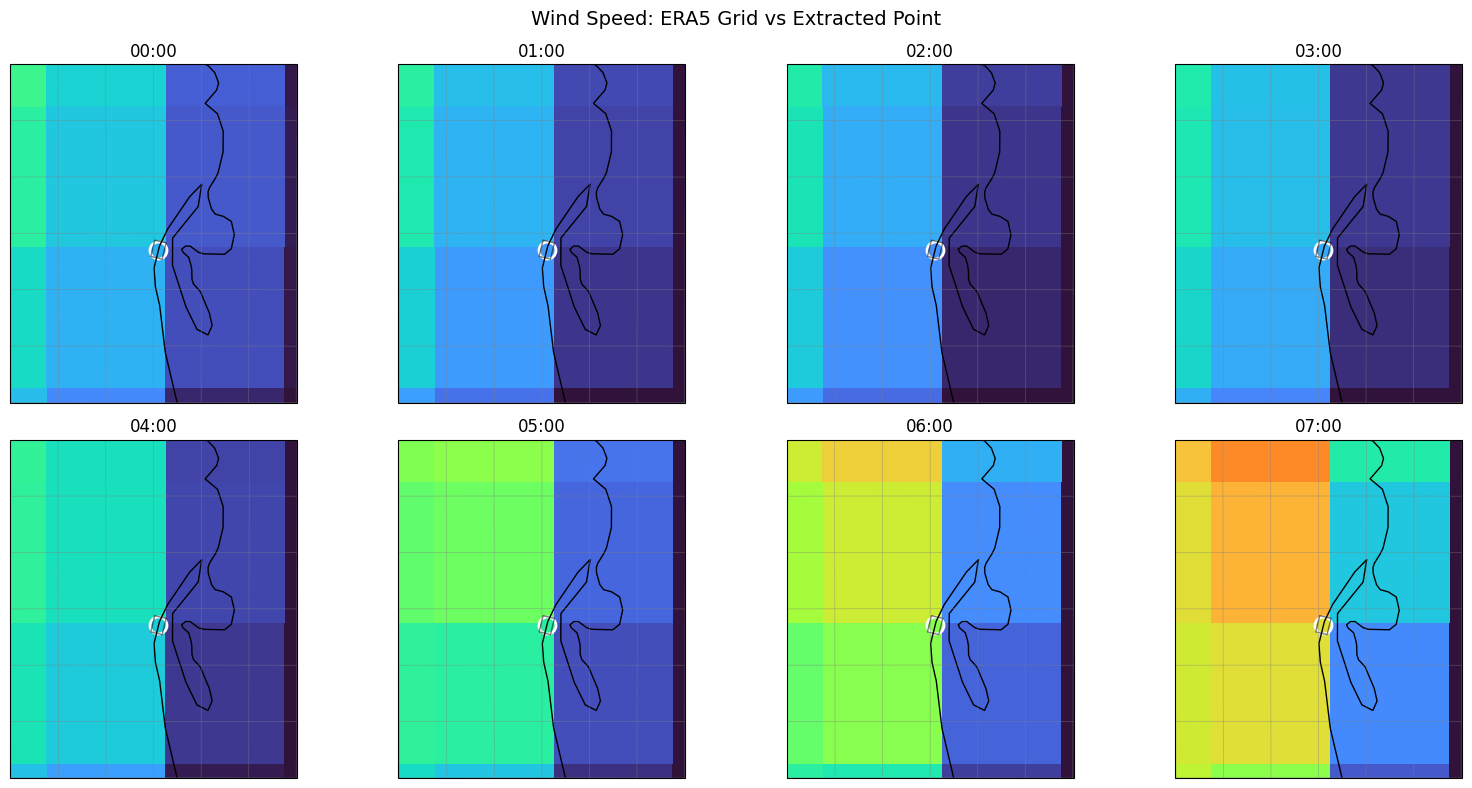

In [9]:
# Load source data for comparison
dset = source.open().sel(time=slice(times.start, times.end))
wspd_source = (dset.u10 ** 2 + dset.v10 ** 2) ** 0.5

fig, axs = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(projection=grid.projection))

for i, ax in enumerate(axs.flat):
    if i >= len(df):
        ax.axis("off")
        continue

    ax.coastlines()

    # Plot source gridded data
    wspd_source.isel(time=i).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmin=4, vmax=14,
        cmap="turbo",
        add_colorbar=False,
    )

    # Plot extracted point (grid centre)
    ax.scatter(
        grid.centre[0], grid.centre[1],
        s=150, c=df.iloc[i].wspd,
        transform=grid.transform,
        vmin=4, vmax=14, cmap="turbo",
        edgecolor="white", linewidth=2,
    )

    # Plot grid outline
    grid.plot(
        ax=ax,
        grid_kwargs=dict(facecolor="none", edgecolor="black", alpha=0.5),
        set_gridlines=False, show_origin=False, show_offshore=False,
    )

    ax.set_extent([115.3, 115.9, -32.9, -32.3])
    ax.set_title(f"{df.index[i]:%H:%M}")

plt.suptitle("Wind Speed: ERA5 Grid vs Extracted Point", fontsize=14)
plt.tight_layout()

## 1.2 Wind from Station Data (`WindStation`)

Extract wind from station-based data with spatial coordinates.

In [10]:
from rompy_xbeach.data.wind import WindStation

In [11]:
destdir = OUT_DIR / "wind_station"
destdir.mkdir(exist_ok=True)

# Station data source
source = SourceCRSFile(
    uri=DATA_DIR / "smc-params-20230101.nc",
    crs=4326,
)

# Wind variables
wind_vars = WindVector(u="uwnd", v="vwnd")

# Create wind forcing with IDW interpolation
wind = WindStation(
    source=source,
    coords=dict(s="seapoint"),
    wind_vars=wind_vars,
    sel_method="idw",
    sel_method_kwargs=dict(tolerance=0.2),
)

params = wind.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ windfile = wind-20230101T000000-20230101T120000.txt        │
└────────────────────────────────────────────────────────────┘


In [12]:
# Inspect the generated file
windfile = destdir / params["windfile"]
print_file(windfile)

┌────────────────────────────────────────────────────────────┐
│ wind-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00       7.15     186.92                                 │
│    3600.00       7.49     192.82                           │
│    7200.00       7.96     198.03                           │
│   10800.00       8.24     203.33                           │
│   14400.00       8.91     208.57                           │
│   18000.00       9.69     210.79                           │
│   21600.00      10.09     210.59                           │
│   25200.00      10.29     210.61                           │
│   28800.00      10.20     209.83                           │
│   32400.00      10.26     209.25                           │
│   36000.00      10.74     209.04                           │
│   39600.00      11.03     204.15                           │
│   43200.00      10.76     199.61                     

In [13]:
# Load generated data
df = pd.read_csv(windfile, header=None, sep=r"\s+", names=["tsec", "wspd", "wdir"])
df["time"] = [times.start + timedelta(seconds=s) for s in df.tsec]
df.set_index("time", inplace=True)

# Load source data
dset = source.open().sel(time=slice(times.start, times.end))
wspd_source = (dset.uwnd ** 2 + dset.vwnd ** 2) ** 0.5

### Visualize: Station Data vs Extracted Point

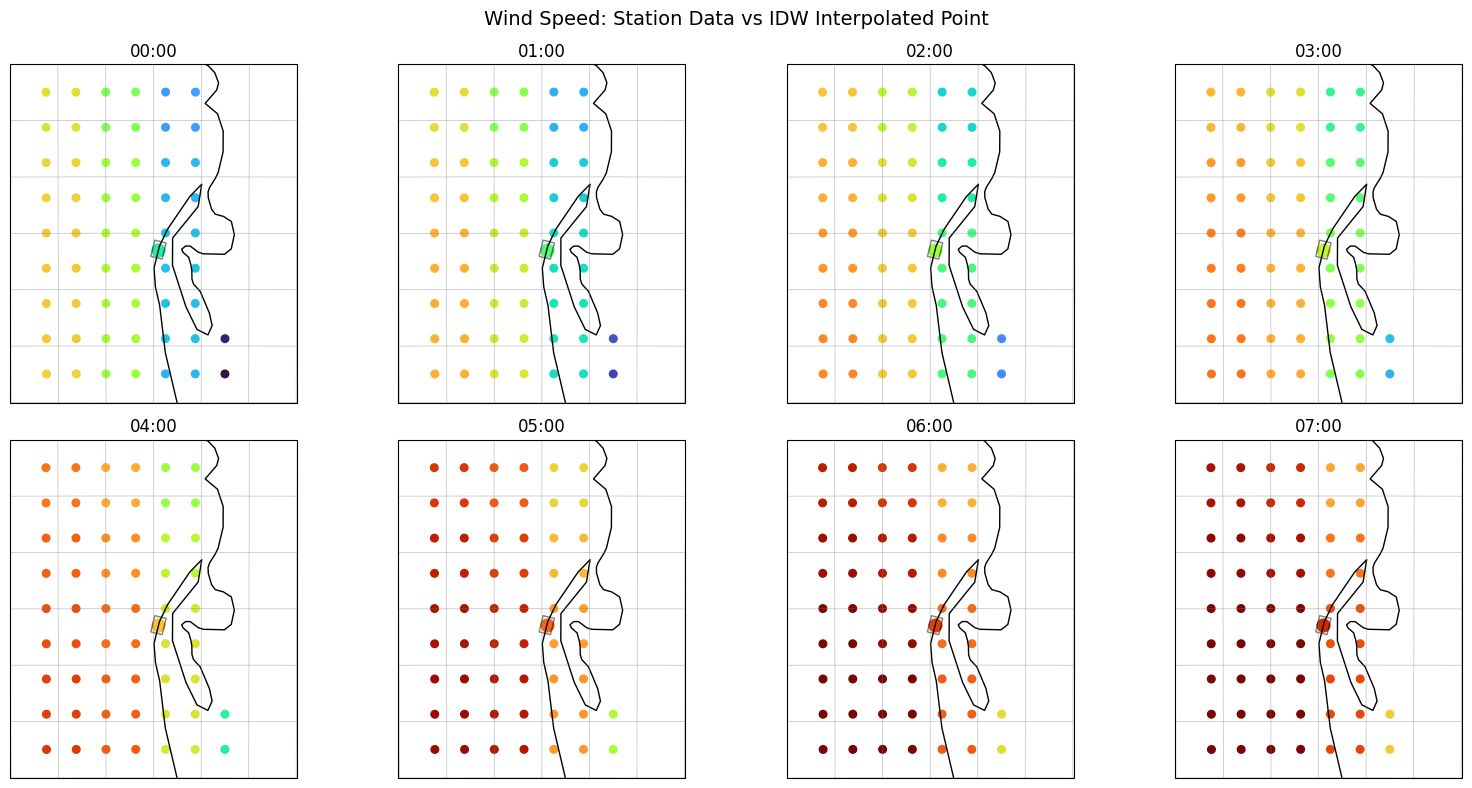

In [14]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(projection=grid.projection))

for i, ax in enumerate(axs.flat):
    if i >= len(df):
        ax.axis("off")
        continue

    ax.coastlines()

    # Plot source station data
    ax.scatter(
        dset.longitude, dset.latitude,
        s=30, c=wspd_source.isel(time=i),
        transform=ccrs.PlateCarree(),
        vmin=5, vmax=11, cmap="turbo",
    )

    # Plot extracted point (grid centre)
    ax.scatter(
        grid.centre[0], grid.centre[1],
        s=150, c=df.iloc[i].wspd,
        transform=grid.transform,
        vmin=5, vmax=11, cmap="turbo",
        edgecolor="white", linewidth=2,
    )

    # Plot grid outline
    grid.plot(
        ax=ax,
        grid_kwargs=dict(facecolor="none", edgecolor="black", alpha=0.5),
        set_gridlines=False, show_origin=False, show_offshore=False,
    )

    ax.set_extent([115.3, 115.9, -32.9, -32.3])
    ax.set_title(f"{df.index[i]:%H:%M}")

plt.suptitle("Wind Speed: Station Data vs IDW Interpolated Point", fontsize=14)
plt.tight_layout()

### Location Options

By default, data is extracted at the grid centre. Use `location="offshore"` to
extract at the offshore boundary midpoint instead:

In [15]:
wind_offshore = WindStation(
    source=source,
    coords=dict(s="seapoint"),
    wind_vars=wind_vars,
    location="offshore",  # Extract at offshore boundary
)

params_offshore = wind_offshore.get(destdir=destdir, grid=grid, time=times)
print_params(params_offshore)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ windfile = wind-20230101T000000-20230101T120000.txt        │
└────────────────────────────────────────────────────────────┘


---
# Part 2: Tide Forcing

Tide forcing in XBeach is defined by a timeseries of water surface elevation.
rompy-xbeach can generate this from:

- **Tidal constituents** (harmonic analysis) - `TideConsGrid`, `TideConsPoint`
- **Water level timeseries** - `WaterLevelGrid`, `WaterLevelStation`, `WaterLevelPoint`

## 2.1 Tide from Gridded Constituents (`TideConsGrid`)

Generate tide timeseries from gridded tidal constituent data (e.g., OTIS, FES).

In [16]:
from rompy_xbeach.source import SourceCRSOceantide
from rompy_xbeach.data.waterlevel import TideConsGrid

In [17]:
destdir = OUT_DIR / "tide_cons_grid"
destdir.mkdir(exist_ok=True)

# Tidal constituent source (OTIS binary format)
source = SourceCRSOceantide(
    reader="read_otis_binary",
    kwargs=dict(
        gfile=DATA_DIR / "swaus_tide_cons/grid_m2s2n2k2k1o1p1q1mmmf",
        hfile=DATA_DIR / "swaus_tide_cons/h_m2s2n2k2k1o1p1q1mmmf",
        ufile=DATA_DIR / "swaus_tide_cons/u_m2s2n2k2k1o1p1q1mmmf",
    ),
    crs=4326,
    x_dim="lon",
    y_dim="lat",
)

# Create tide forcing
tide = TideConsGrid(
    source=source,
    coords=dict(x="lon", y="lat"),
)

params = tide.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ zs0file = tide-20230101T000000-20230101T120000.txt         │
│ tideloc = 1                                                │
│ tidelen = 13                                               │
└────────────────────────────────────────────────────────────┘


In [18]:
# Inspect the generated tide file
tidefile = destdir / params["zs0file"]
print_file(tidefile)

┌────────────────────────────────────────────────────────────┐
│ tide-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00      -0.12                                            │
│    3600.00      -0.10                                      │
│    7200.00      -0.07                                      │
│   10800.00      -0.04                                      │
│   14400.00       0.00                                      │
│   18000.00       0.05                                      │
│   21600.00       0.09                                      │
│   25200.00       0.14                                      │
│   28800.00       0.17                                      │
│   32400.00       0.20                                      │
│   36000.00       0.21                                      │
│   39600.00       0.21                                      │
│   43200.00       0.19                                

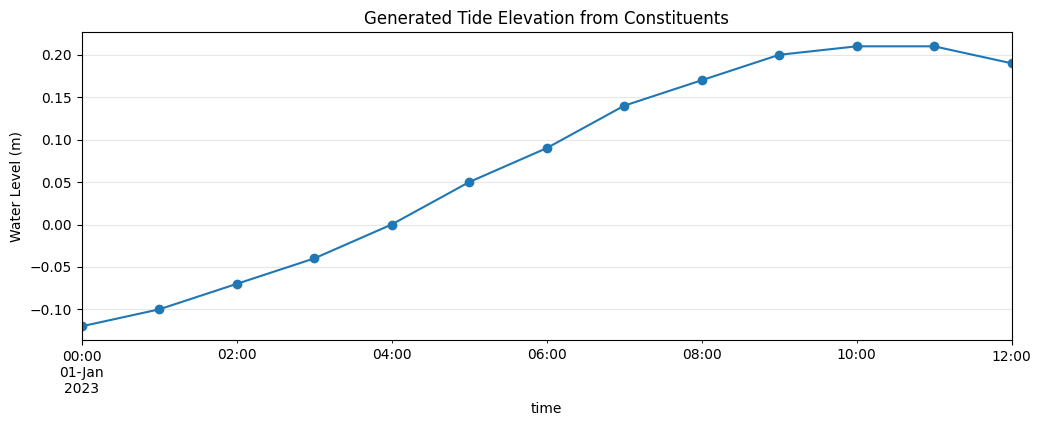

In [19]:
# Load and plot the tide timeseries
df = pd.read_csv(tidefile, header=None, sep=r"\s+", names=["tsec", "zs"])
df["time"] = [times.start + timedelta(seconds=s) for s in df.tsec]
df.set_index("time", inplace=True)

fig, ax = plt.subplots(figsize=(12, 4))
df.zs.plot(ax=ax, marker="o")
ax.set_ylabel("Water Level (m)")
ax.set_title("Generated Tide Elevation from Constituents")
ax.grid(True, alpha=0.3)

## 2.2 Tide from Point Constituents (`TideConsPoint`)

Generate tide from constituent data for a single location (e.g., from a tide gauge).

In [20]:
from rompy_xbeach.source import SourceTideConsPointCSV
from rompy_xbeach.data.waterlevel import TideConsPoint

In [21]:
destdir = OUT_DIR / "tide_cons_point"
destdir.mkdir(exist_ok=True)

# Point constituent source (CSV format)
source = SourceTideConsPointCSV(
    filename=DATA_DIR / "tide_cons_station.csv",
    acol="amplitude",
    pcol="phase",
    ccol="constituent",
)

# Create tide forcing
tide = TideConsPoint(source=source)

params = tide.get(destdir=destdir, grid=grid, time=times)
print_params(params)

┌────────────────────────────────────────────────────────────┐
│ params.txt                                                 │
├────────────────────────────────────────────────────────────┤
│ zs0file = tide-20230101T000000-20230101T120000.txt         │
│ tideloc = 1                                                │
│ tidelen = 13                                               │
└────────────────────────────────────────────────────────────┘


In [22]:
# Inspect the generated file
tidefile = destdir / params["zs0file"]
print_file(tidefile)

┌────────────────────────────────────────────────────────────┐
│ tide-20230101T000000-20230101T120000.txt                   │
├────────────────────────────────────────────────────────────┤
│ 0.00      -0.20                                            │
│    3600.00      -0.15                                      │
│    7200.00      -0.09                                      │
│   10800.00      -0.02                                      │
│   14400.00       0.06                                      │
│   18000.00       0.13                                      │
│   21600.00       0.19                                      │
│   25200.00       0.24                                      │
│   28800.00       0.26                                      │
│   32400.00       0.26                                      │
│   36000.00       0.23                                      │
│   39600.00       0.20                                      │
│   43200.00       0.15                                

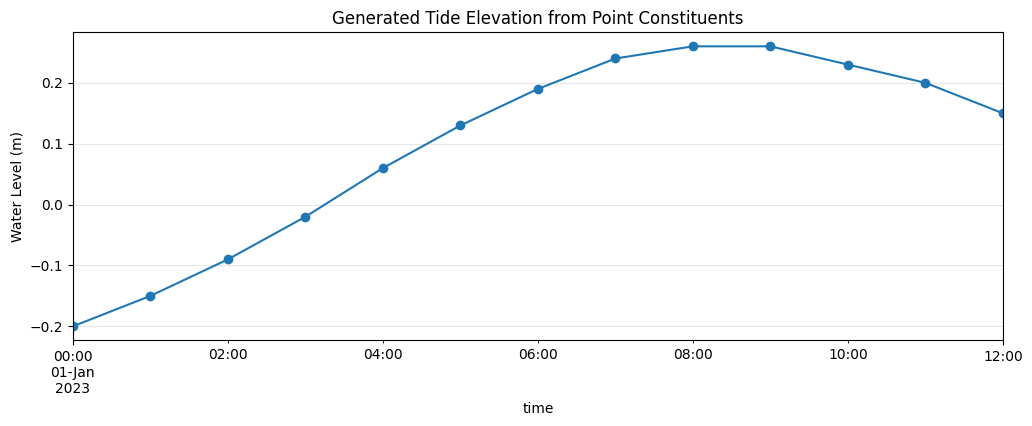

In [23]:
# Plot the tide timeseries
df = pd.read_csv(tidefile, header=None, sep=r"\s+", names=["tsec", "zs"])
df["time"] = [times.start + timedelta(seconds=s) for s in df.tsec]
df.set_index("time", inplace=True)

fig, ax = plt.subplots(figsize=(12, 4))
df.zs.plot(ax=ax, marker="o")
ax.set_ylabel("Water Level (m)")
ax.set_title("Generated Tide Elevation from Point Constituents")
ax.grid(True, alpha=0.3)

## 2.3 Water Level from Gridded Data (`WaterLevelGrid`)

Use water level timeseries directly (e.g., from a storm surge model).

In [24]:
from rompy_xbeach.data.waterlevel import WaterLevelGrid

In [25]:
destdir = OUT_DIR / "waterlevel_grid"
destdir.mkdir(exist_ok=True)

# Use ERA5 mean sea level pressure as a proxy (for demonstration)
# In practice, you would use actual water level data
source = SourceCRSFile(
    uri=DATA_DIR / "era5-20230101.nc",
    crs=4326,
)

# Note: This is just for demonstration - ERA5 doesn't have water level
# In real use, you would have a dataset with sea surface height
# waterlevel = WaterLevelGrid(
#     source=source,
#     coords=dict(x="longitude", y="latitude"),
#     variables=["ssh"],
# )

print("WaterLevelGrid: Use with gridded water level data (e.g., storm surge model output)")

WaterLevelGrid: Use with gridded water level data (e.g., storm surge model output)


## 2.4 Water Level from Station Data (`WaterLevelStation`)

Extract water level from station-based timeseries data.

In [26]:
from rompy_xbeach.data.waterlevel import WaterLevelStation

print("WaterLevelStation: Use with station-based water level data")
print("  - Similar to WindStation but for water level")
print("  - Supports IDW and nearest neighbour interpolation")

WaterLevelStation: Use with station-based water level data
  - Similar to WindStation but for water level
  - Supports IDW and nearest neighbour interpolation


---
# Part 3: Using in Config

Forcing objects are passed to `Config.input` to define model forcing.

In [27]:
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import XBeachBathy

# Create bathymetry
bathy = XBeachBathy(
    source={"model_type": "geotiff", "filename": str(DATA_DIR / "bathy.tif")}
)

# Create forcing objects
wind = WindGrid(
    source=SourceCRSFile(uri=DATA_DIR / "era5-20230101.nc", crs=4326),
    coords=dict(x="longitude", y="latitude"),
    wind_vars=WindVector(u="u10", v="v10"),
)

tide = TideConsPoint(
    source=SourceTideConsPointCSV(
        filename=DATA_DIR / "tide_cons_station.csv",
        acol="amplitude", pcol="phase", ccol="constituent",
    )
)

# Create config with forcing
config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(
        wind=wind,
        tide=tide,
    ),
)

print("Config created with wind and tide forcing")
print(f"  Wind type: {type(config.input.wind).__name__}")
print(f"  Tide type: {type(config.input.tide).__name__}")

Config created with wind and tide forcing
  Wind type: WindGrid
  Tide type: TideConsPoint


---
# Summary

## Forcing Classes

| Class | Source Type | Use Case |
|-------|-------------|----------|
| `WindGrid` | Gridded | ERA5, GFS, etc. |
| `WindStation` | Station | Point observations with coordinates |
| `WindPoint` | Timeseries | CSV/DataFrame (see Bulk Forcing Tutorial) |
| `TideConsGrid` | Gridded constituents | OTIS, FES, etc. |
| `TideConsPoint` | Point constituents | Single location harmonics |
| `WaterLevelGrid` | Gridded timeseries | Storm surge models |
| `WaterLevelStation` | Station timeseries | Tide gauge networks |
| `WaterLevelPoint` | Timeseries | CSV/DataFrame (see Bulk Forcing Tutorial) |

## Key Points

- **Grid/Station** classes extract data at grid centre or offshore boundary
- **Point** classes use timeseries directly (no spatial selection)
- Wind can be specified as **vector** (u, v) or **scalar** (speed, direction)
- Tide can be from **constituents** (harmonic) or **timeseries** (direct)

## Next Steps

- See **Bulk Forcing Tutorial** for CSV/DataFrame-based forcing
- See **Wave Boundary Tutorial** for wave boundary conditions
- See **Config Tutorial** for complete model setup